<a href="https://colab.research.google.com/github/zaibshahzadi/DL-Internship/blob/main/Deep_Learning_Apple_Stock_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
df = pd.read_csv("AAPL.csv")

print(df.head())

         Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.128348  0.128906  0.128348  0.128348   0.100323  469033600
1  1980-12-15  0.122210  0.122210  0.121652  0.121652   0.095089  175884800
2  1980-12-16  0.113281  0.113281  0.112723  0.112723   0.088110  105728000
3  1980-12-17  0.115513  0.116071  0.115513  0.115513   0.090291   86441600
4  1980-12-18  0.118862  0.119420  0.118862  0.118862   0.092908   73449600


In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (10409, 7)

Columns:
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

Data Types:
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

Missing Values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

print(df.dtypes)

Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object


In [ ]:
df = df.sort_values('Date')

df = df.reset_index(drop=True)

print(df.head())
print(df.tail())

        Date      Open      High       Low     Close  Adj Close     Volume
0 1980-12-12  0.128348  0.128906  0.128348  0.128348   0.100323  469033600
1 1980-12-15  0.122210  0.122210  0.121652  0.121652   0.095089  175884800
2 1980-12-16  0.113281  0.113281  0.112723  0.112723   0.088110  105728000
3 1980-12-17  0.115513  0.116071  0.115513  0.115513   0.090291   86441600
4 1980-12-18  0.118862  0.119420  0.118862  0.118862   0.092908   73449600
            Date        Open        High         Low       Close   Adj Close  \
10404 2022-03-18  160.509995  164.479996  159.759995  163.979996  163.979996   
10405 2022-03-21  163.509995  166.350006  163.009995  165.380005  165.380005   
10406 2022-03-22  165.509995  169.419998  164.910004  168.820007  168.820007   
10407 2022-03-23  167.990005  172.639999  167.649994  170.210007  170.210007   
10408 2022-03-24  171.059998  174.139999  170.210007  174.070007  174.070007   

          Volume  
10404  123351200  
10405   95811400  
10406   8153

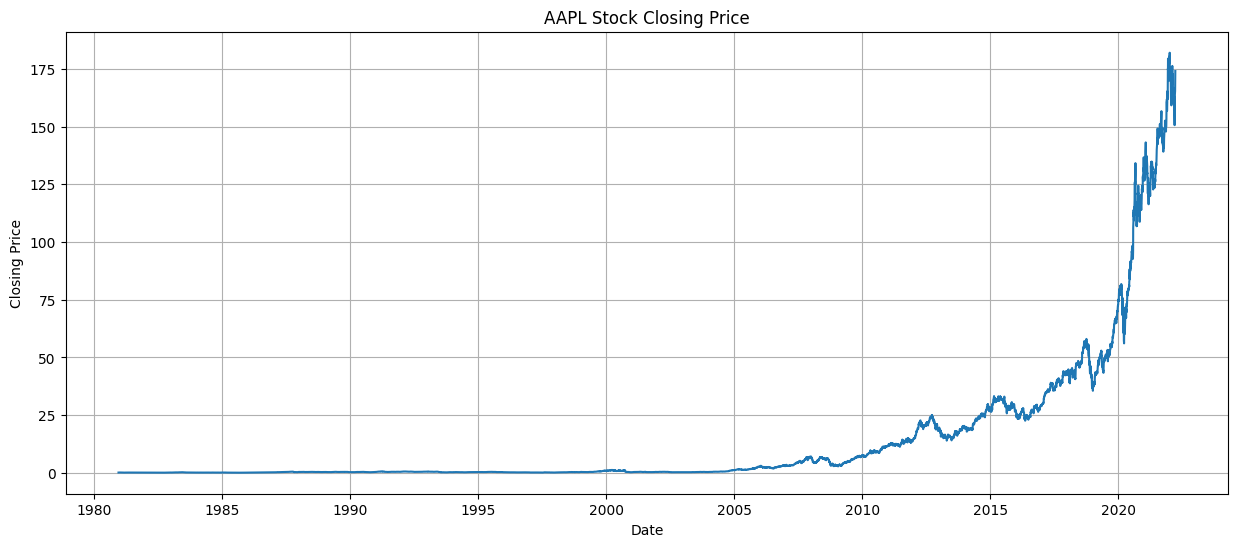

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(df['Date'], df['Close'])

plt.title('AAPL Stock Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.grid(True)
plt.show()

In [ ]:
data = df[['Date', 'Close']].copy()

print(data.head())

        Date     Close
0 1980-12-12  0.128348
1 1980-12-15  0.121652
2 1980-12-16  0.112723
3 1980-12-17  0.115513
4 1980-12-18  0.118862


In [ ]:
train_size = int(len(data) * 0.80)

train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

print("Total records:", len(data))
print("Training records:", len(train_data))
print("Testing records:", len(test_data))

Total records: 10409
Training records: 8327
Testing records: 2082


In [ ]:
train_prices = train_data['Close'].values.reshape(-1, 1)
test_prices = test_data['Close'].values.reshape(-1, 1)

print("Training shape:", train_prices.shape)
print("Testing shape:", test_prices.shape)

Training shape: (8327, 1)
Testing shape: (2082, 1)


In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train_prices)

test_scaled = scaler.transform(test_prices)

print(train_scaled[:5])

[[0.00316636]
 [0.0028988 ]
 [0.00254201]
 [0.00265349]
 [0.00278731]]


In [ ]:
sequence_length = 60

In [ ]:
def create_sequences(data, sequence_length):
    X = []
    y = []

    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [ ]:
X_train, y_train = create_sequences(
    train_scaled,
    sequence_length
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (8267, 60, 1)
y_train shape: (8267, 1)


In [ ]:
test_input = np.concatenate(
    [train_scaled[-sequence_length:], test_scaled]
)

X_test, y_test = create_sequences(
    test_input,
    sequence_length
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (2082, 60, 1)
y_test shape: (2082, 1)


In [ ]:
lstm_model = Sequential([

    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),

    Dropout(0.2),

    LSTM(64),

    Dropout(0.2),

    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    shuffle=False
)

Epoch 1/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - loss: 4.5945e-04 - val_loss: 0.0584
Epoch 2/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - loss: 9.8856e-04 - val_loss: 0.0201
Epoch 3/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - loss: 0.0026 - val_loss: 0.1427
Epoch 4/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - loss: 0.0016 - val_loss: 0.0113
Epoch 5/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - loss: 0.0010 - val_loss: 0.0755
Epoch 6/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - loss: 3.3471e-04 - val_loss: 0.0221
Epoch 7/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - loss: 2.6194e-04 - val_loss: 0.0448
Epoch 8/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - loss: 2.1575e-04 - val_loss: 0.0255
Epoch 9/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - loss: 1.9980e-04 - val_loss: 0.0169
Epoch 10/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - loss: 2.7422e-04 - val_loss: 0.0182
Epoch 11/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - loss: 2.3817e-04 - val_loss: 0.009

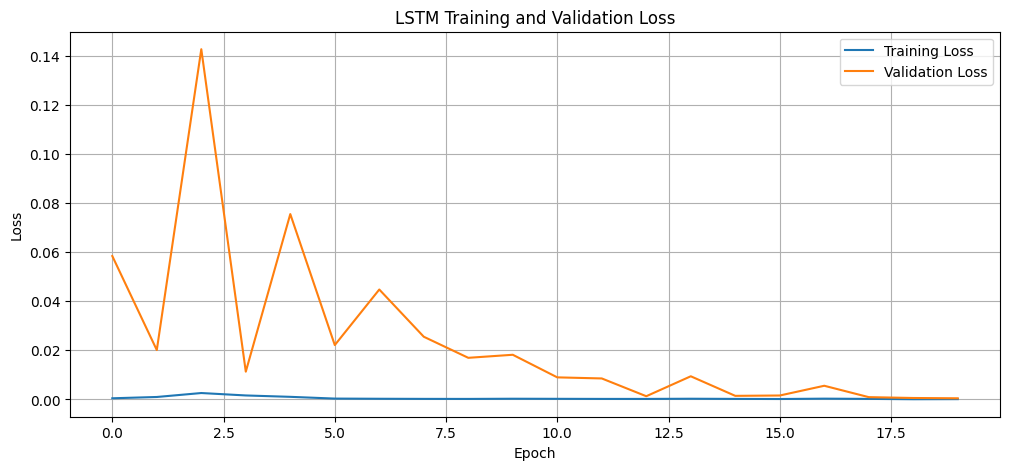

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
lstm_predictions_scaled = lstm_model.predict(X_test)

print(lstm_predictions_scaled.shape)

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
(2082, 1)


In [ ]:
lstm_predictions = scaler.inverse_transform(
    lstm_predictions_scaled
)

actual_prices = scaler.inverse_transform(
    y_test
)

In [ ]:
lstm_rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        lstm_predictions
    )
)

lstm_mae = mean_absolute_error(
    actual_prices,
    lstm_predictions
)

print("LSTM RMSE:", lstm_rmse)
print("LSTM MAE:", lstm_mae)

LSTM RMSE: 28.820376732455873
LSTM MAE: 13.909528224822969


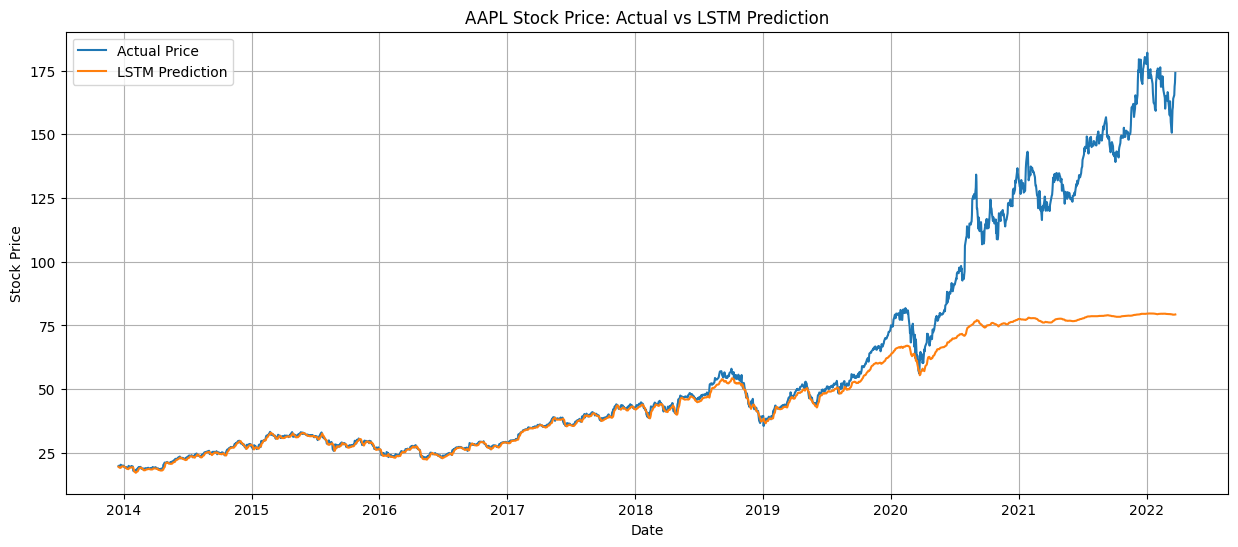

In [ ]:
test_dates = test_data['Date'].values

plt.figure(figsize=(15, 6))

plt.plot(
    test_dates,
    actual_prices,
    label='Actual Price'
)

plt.plot(
    test_dates,
    lstm_predictions,
    label='LSTM Prediction'
)

plt.title('AAPL Stock Price: Actual vs LSTM Prediction')

plt.xlabel('Date')
plt.ylabel('Stock Price')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
gru_model = Sequential([

    GRU(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),

    Dropout(0.2),

    GRU(64),

    Dropout(0.2),

    Dense(1)
])

gru_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

gru_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,889 (148.00 KB)

 Trainable params: 37,889 (148.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    shuffle=False
)

Epoch 1/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 22s 80ms/step - loss: 4.6009e-04 - val_loss: 0.0332
Epoch 2/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 17s 73ms/step - loss: 0.0016 - val_loss: 0.0358
Epoch 3/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 18s 75ms/step - loss: 0.0029 - val_loss: 0.1000
Epoch 4/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 19s 80ms/step - loss: 0.0015 - val_loss: 0.0166
Epoch 5/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 20s 76ms/step - loss: 6.7755e-04 - val_loss: 0.0032
Epoch 6/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 18s 77ms/step - loss: 2.0134e-04 - val_loss: 0.0073
Epoch 7/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 18s 79ms/step - loss: 1.1123e-04 - val_loss: 0.0058
Epoch 8/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - loss: 1.4488e-04 - val_loss: 0.0036
Epoch 9/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - loss: 2.1402e-04 - val_loss: 0.0062
Epoch 10/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - loss: 2.3737e-04 - val_loss: 0.0064
Epoch 11/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 22s 85ms/step - loss: 1.2933e-04 - val_loss: 0.002

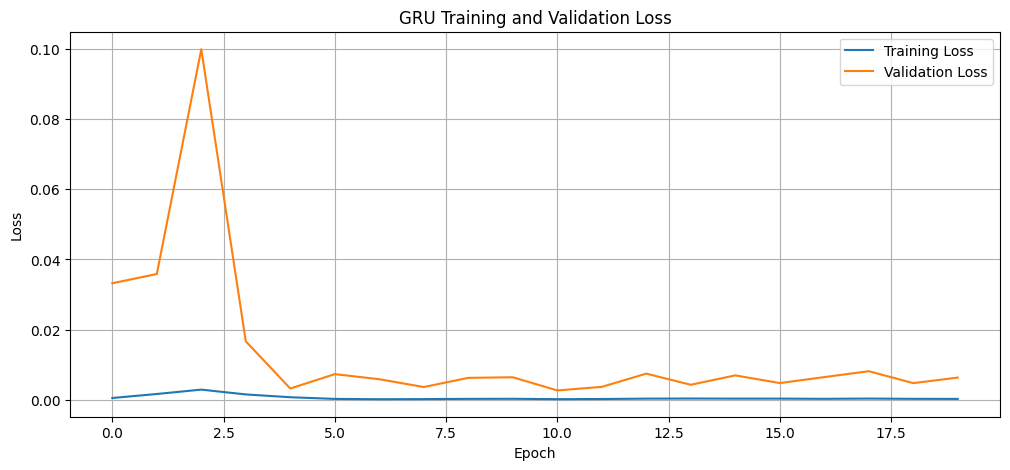

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(history_gru.history['loss'], label='Training Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')

plt.title('GRU Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
gru_predictions_scaled = gru_model.predict(X_test)

gru_predictions = scaler.inverse_transform(
    gru_predictions_scaled
)

66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step


In [ ]:
gru_rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        gru_predictions
    )
)

gru_mae = mean_absolute_error(
    actual_prices,
    gru_predictions
)

print("GRU RMSE:", gru_rmse)
print("GRU MAE:", gru_mae)

GRU RMSE: 28.407960224466965
GRU MAE: 16.409994071527453


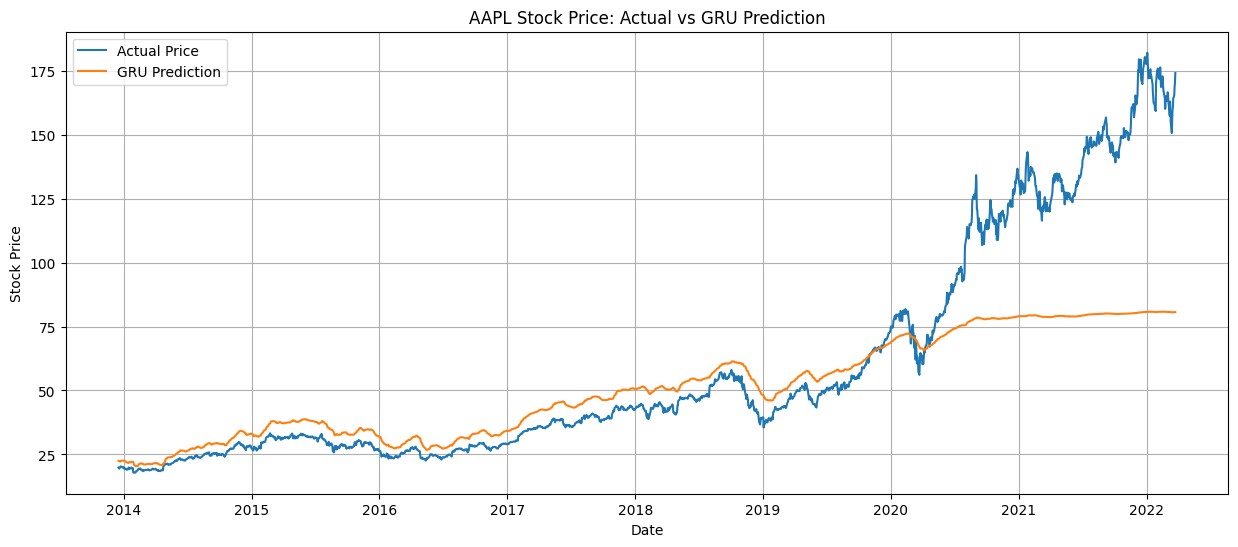

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    test_dates,
    actual_prices,
    label='Actual Price'
)

plt.plot(
    test_dates,
    gru_predictions,
    label='GRU Prediction'
)

plt.title('AAPL Stock Price: Actual vs GRU Prediction')

plt.xlabel('Date')
plt.ylabel('Stock Price')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
comparison = pd.DataFrame({
    'Model': ['LSTM', 'GRU'],
    'RMSE': [lstm_rmse, gru_rmse],
    'MAE': [lstm_mae, gru_mae]
})

print(comparison)

  Model       RMSE        MAE
0  LSTM  28.820377  13.909528
1   GRU  28.407960  16.409994


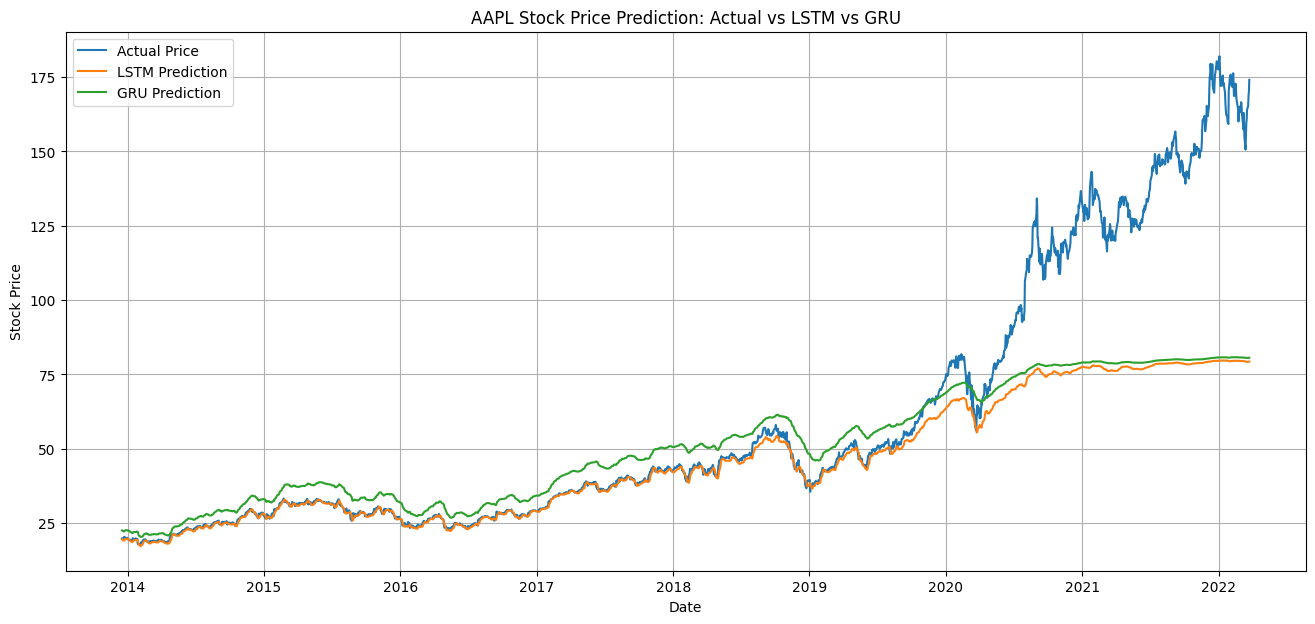

In [ ]:
plt.figure(figsize=(16, 7))

plt.plot(
    test_dates,
    actual_prices,
    label='Actual Price'
)

plt.plot(
    test_dates,
    lstm_predictions,
    label='LSTM Prediction'
)

plt.plot(
    test_dates,
    gru_predictions,
    label='GRU Prediction'
)

plt.title('AAPL Stock Price Prediction: Actual vs LSTM vs GRU')

plt.xlabel('Date')
plt.ylabel('Stock Price')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
results = pd.DataFrame({
    'Date': test_dates,
    'Actual Price': actual_prices.flatten(),
    'LSTM Prediction': lstm_predictions.flatten(),
    'GRU Prediction': gru_predictions.flatten()
})

print(results.head(20))

         Date  Actual Price  LSTM Prediction  GRU Prediction
0  2013-12-17     19.821072        19.540951       22.516130
1  2013-12-18     19.670357        19.451033       22.475958
2  2013-12-19     19.445000        19.343344       22.399845
3  2013-12-20     19.607857        19.190348       22.271549
4  2013-12-23     20.360357        19.117136       22.212746
5  2013-12-24     20.273930        19.325190       22.395008
6  2013-12-26     20.139286        19.545713       22.541315
7  2013-12-27     20.003214        19.687920       22.603989
8  2013-12-30     19.804285        19.729746       22.600883
9  2013-12-31     20.036428        19.663063       22.534817
10 2014-01-02     19.754642        19.646944       22.543562
11 2014-01-03     19.320715        19.552349       22.482222
12 2014-01-06     19.426071        19.321980       22.299648
13 2014-01-07     19.287144        19.139420       22.172602
14 2014-01-08     19.409286        18.968391       22.045732
15 2014-01-09     19.161

In [ ]:
results.to_csv(
    'AAPL_LSTM_GRU_predictions.csv',
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [ ]:
from google.colab import files

files.download('AAPL_LSTM_GRU_predictions.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>